In [1]:
rm(list = ls())

# check and install CRAN packages
cran_packages <- c("data.table", "reshape2", "pheatmap", "ggseqlogo", "ggplot2")

for (pkg in cran_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, dependencies = TRUE)
  }
}

lapply(cran_packages, library, character.only = TRUE)


Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt




[[1]]
[1] "data.table" "repr"       "stats"      "graphics"   "grDevices" 
[6] "utils"      "datasets"   "methods"    "base"      

[[2]]
 [1] "reshape2"   "data.table" "repr"       "stats"      "graphics"  
 [6] "grDevices"  "utils"      "datasets"   "methods"    "base"      

[[3]]
 [1] "pheatmap"   "reshape2"   "data.table" "repr"       "stats"     
 [6] "graphics"   "grDevices"  "utils"      "datasets"   "methods"   
[11] "base"      

[[4]]
 [1] "ggseqlogo"  "pheatmap"   "reshape2"   "data.table" "repr"      
 [6] "stats"      "graphics"   "grDevices"  "utils"      "datasets"  
[11] "methods"    "base"      

[[5]]
 [1] "ggplot2"    "ggseqlogo"  "pheatmap"   "reshape2"   "data.table"
 [6] "repr"       "stats"      "graphics"   "grDevices"  "utils"     
[11] "datasets"   "methods"    "base"

# Figure S3a

In [2]:
fasta <- read.delim2("./lib/srna_trigger_seqs.txt", sep = "\t", header = TRUE)
unisRNA <- unique(fasta$sRNA)

for(i in 1:length(unisRNA)){
  pdata <- fasta$Sequence[fasta$sRNA == unisRNA[i]]
  p <- ggplot() + 
    geom_logo(pdata) + theme_logo() + theme_classic() +
    scale_x_continuous(breaks = seq(0, 21, by = 3), expand = c(0.01, 0))

  # save plot
  wrfile <- paste(unisRNA[i], ".pdf", sep = "")
  ggsave(p, file = wrfile, height = 1.2, width = 4.3)
}

Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as of ggplot2 3.3.4.
ℹ The deprecated feature was likely used in the ggseqlogo package.
  Please report the issue at <https://github.com/omarwagih/ggseqlogo/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggseqlogo package.
  Please report the issue at <https://github.com/omarwagih/ggseqlogo/issues>.”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is 

# Figure S3b

In [3]:
# load target prediction data
files <- list.files(path = "./lib/psRNATarget/", pattern = "psRNATargetJob")
fname <- paste0("./lib/psRNATarget/", files)

temp <- rbindlist(
  lapply(fname, function(f) {
    fread(f, sep = "\t", comment.char = "#", data.table = FALSE)[, 1:3]
  }),
  use.names = TRUE
) |> unique()

temp$Target_Acc. <- sub("\\..*$", "", temp$Target_Acc.)
setorder(temp, Expectation)
temp$ID <- paste(temp$miRNA_Acc., temp$Target_Acc., sep = "%")

# only use hotspot-siRNA-PPR
pprlist <- fread("./lib/hotspot_control_sirna_ppr_accs.txt", header = FALSE)[[1]]

temp <- temp[temp$Target_Acc. %in% pprlist, ]

temp <- temp[!duplicated(temp$ID), 
             c("miRNA_Acc.", "Target_Acc.", "Expectation")]

pdata <- dcast(temp, miRNA_Acc. ~ Target_Acc., value.var = "Expectation")
rownames(pdata) <- pdata$miRNA_Acc.
pdata$miRNA_Acc. <- NULL

pdata <- as.matrix(pdata)
mode(pdata) <- "numeric"
pdata[is.na(pdata)] <- max(pdata, na.rm = TRUE) + 2

# order as Figure 2
order_ids <- fread("./lib/pheatmap_gene_order.txt", header = FALSE)[[1]]
pdata <- pdata[, order_ids, drop = FALSE]


In [4]:
# set column order
row_ids <- c("TAS1c_3D6", "TAS2_3D12", "TAS1c_3D10",
             "TAS1b_3D4", "TAS2_3D9", "TAS2_3D11",
             "miR400", "TAS1a_3D9", "TAS2_3D6",
             "miR161.1", "miR161.2")

row_labels <- c("TAS1c 3'D6(-)", "TAS2 3'D12(-)", "TAS1c 3'D10(-)",
                "TAS1b 3'D4(-)", "TAS2 3'D9(-)", "TAS2 3'D11(-)",
                "miR400", "TAS1a 3'D9(-)", "TAS2 3'D6(-)",
                "miR161.1", "miR161.2")

pdata <- pdata[row_ids, ]
rownames(pdata) <- row_labels

In [5]:
# load gene order data
order_ids <- fread("./lib/pheatmap_gene_order.txt", header = FALSE)[[1]]
gene_id <- data.frame(ID = order_ids, stringsAsFactors = FALSE)
gene_id$Accession <- sapply(gene_id$ID, function(x) unlist(strsplit(x, "-"))[1])

accession_mapping <- c(
  "ATCT" = "Ct-1", "ATCol" = "Col-0", "ATAN" = "An-1",
  "ATERI" = "Eri-1", "ATLER" = "Ler-0", "ATKYO" = "Kyo-1",
  "ATSHA" = "Sha", "ATCVI" = "Cvi-1"
)
gene_id$Accession <- accession_mapping[gene_id$Accession]
gene_id$Class <- "hotspot"
gene_id$Class[grep("-5G", gene_id$ID)] <- "other"       

In [6]:
# load annotation data
group <- read.delim2("./lib/ppr_gene_group.txt", header = TRUE, sep = "\t", check.names = TRUE)
group$PPR <- sub("\\..*$", "", group$PPR)
gene_id$Group <- group$Group[match(gene_id$ID, group$PPR)]

# prepare annotation for pheatmap
annotation <- data.frame(
  Accession = gene_id$Accession,
  Class = gene_id$Class,
  Group = gene_id$Group,
  row.names = sub("\\..*$", "", gene_id$ID),
  stringsAsFactors = FALSE
)
                           
# set annotation colors
ann_colors <- list(
  Class = c("hotspot" = "black", "other" = "lightgrey"),
  Accession = c(
    "An-1" = "#0000FF", "Col-0" = "#FFA500", "Ct-1" = "#FF0000",
    "Cvi-1" = "#800000", "Eri-1" = "#000080", "Kyo-1" = "#008000",
    "Ler-0" = "#800080", "Sha" = "#696969"
  ),
  Group = c("G1" = "#BB86D8", "G2" = "#62CA6F", "G3" = "orange")
)


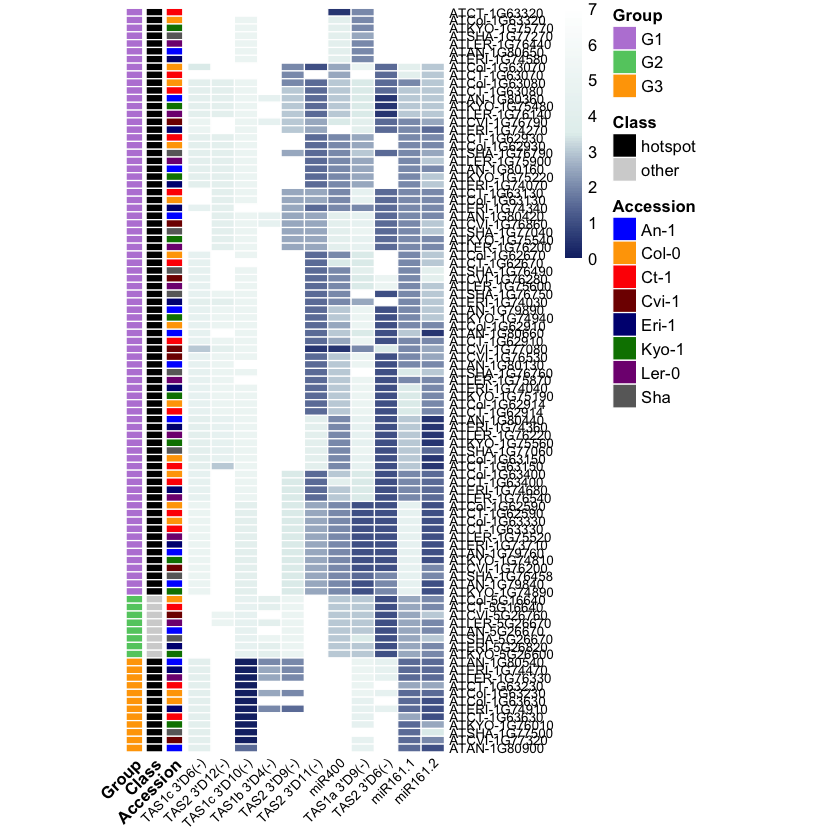

In [7]:
p <- pheatmap(
  t(pdata),
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  annotation_row = annotation, 
  annotation_colors = ann_colors,
  border_color = "white",
  color = colorRampPalette(c("#162D73", "#E4F0EF", "white"))(100),
  fontsize_legend = 6,
  fontsize_row = 8,
  fontsize_col = 8,
  angle_col = 45,
  cellwidth = 14
)

ggsave(p, file = "hotspot_sirna_ppr_target_score.pdf", width = 6, height = 13)

In [8]:
sessionInfo()

R version 4.5.1 (2025-06-13)
Platform: aarch64-apple-darwin23.6.0
Running under: macOS Sonoma 14.5

Matrix products: default
BLAS:   /opt/homebrew/Cellar/openblas/0.3.30/lib/libopenblasp-r0.3.30.dylib 
LAPACK: /opt/homebrew/Cellar/r/4.5.1/lib/R/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] en_GB.UTF-8/en_GB.UTF-8/en_GB.UTF-8/C/en_GB.UTF-8/en_GB.UTF-8

time zone: America/Chicago
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_4.0.1     ggseqlogo_0.2.2   pheatmap_1.0.13   reshape2_1.4.5   
[5] data.table_1.18.0 repr_1.1.7       

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       jsonlite_2.0.0     dplyr_1.1.4        compiler_4.5.1    
 [5] crayon_1.5.3       tidyselect_1.2.1   Rcpp_1.1.0         IRdisplay_1.1     
 [9] stringr_1.6.0      systemfonts_1.3.1  scales_1.4.0       textshaping_1.0.4 
[13] uuid_1.2-1         fastmap_1.2.0      IRkernel_1.3